# Gold Volatility Prediction with XGBoost

Forecasting gold's realised volatility 5 and 22 trading days ahead from HAR
components, macro and cross-asset features, and implied volatility.

Self-contained: run top to bottom. Figures are saved to `report_figures/`. Runtime is roughly 15 minutes, mostly the
hyperparameter search in section 5.

## 1. Setup and Data Loading

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb

from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, confusion_matrix, f1_score,
    mean_absolute_error, mean_squared_error, r2_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import ParameterSampler, TimeSeriesSplit

DATA_PATH = "daily_commodity_market_data_cleaned.csv"
FIG_DIR = "report_figures"

# CBOE GVZ inception; also drops the 2004-2007 gold range data, which is
# unusable (38-55% of days report High == Low)
START_DATE = "2008-06-03"

TEST_FRACTION = 0.20
SEED = 42
N_TUNING_CONFIGS = 40
N_CV_SPLITS = 4

HAR_FEATURES = ["har_daily", "har_weekly", "har_monthly"]

MACRO_FEATURES = [
    "gold_return_1d", "gold_return_5d", "gold_return_20d",
    "gold_volatility_5d", "gold_volatility_20d", "gold_close_pos",
    "gold_volume_change", "gold_relative_volume",
    "crude_oil_return_1d", "silver_return_1d", "copper_return_1d",
    "platinum_return_1d", "us_dollar_index_return_1d", "sp_500_return_1d",
    "eur_usd_return_1d", "vix_change_1d", "breakeven_inflation_10y_diff_bps",
    "us_2_year_treasury_yields_diff_bps", "us_10_year_treasury_yields_diff_bps",
    "two_ten_slope", "two_ten_slope_change_bps",
]

# The only forward-looking block in the feature set
IMPLIED_FEATURES = ["gvz_log", "gvz_change", "gvz_5d", "vrp", "ovx_log"]

ALL_FEATURES = HAR_FEATURES + MACRO_FEATURES + IMPLIED_FEATURES

TUNING_SPACE = {
    "max_depth": [2, 3, 4, 5],
    "min_child_weight": [1, 5, 10, 20, 50],
    "learning_rate": [0.01, 0.02, 0.03, 0.05],
    "n_estimators": [200, 300, 500, 800],
    "subsample": [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.5, 0.6, 0.8, 1.0],
    "reg_lambda": [1.0, 2.0, 5.0, 10.0, 20.0],
    "gamma": [0.0, 0.1, 0.5],
}

os.makedirs(FIG_DIR, exist_ok=True)
pd.set_option("display.width", 200)
np.random.seed(SEED)


def show(name):
    """Save the current figure for the report, then display it."""
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


print(f"{len(ALL_FEATURES)} features: {len(HAR_FEATURES)} HAR, "
      f"{len(MACRO_FEATURES)} macro, {len(IMPLIED_FEATURES)} implied volatility")

29 features: 3 HAR, 21 macro, 5 implied volatility


Volatility metrics: QLIKE, the Diebold-Mariano test, and the smearing correction.

In [2]:
def qlike_loss(y_true, y_pred):
    """Per-observation QLIKE on variance. Zero for a perfect forecast."""
    ratio = y_true ** 2 / y_pred ** 2
    return ratio - np.log(ratio) - 1


def diebold_mariano(loss_a, loss_b, horizon):
    """Test whether model A's loss differs from model B's. Negative favours A."""
    d = np.asarray(loss_a) - np.asarray(loss_b)
    n = len(d)
    d_bar = d.mean()
    dc = d - d_bar
    # Newey-West: overlapping forecast windows autocorrelate the differentials
    var = (dc @ dc) / n
    for lag in range(1, max(horizon, 1)):
        if lag >= n:
            break
        var += 2 * (1 - lag / horizon) * ((dc[lag:] @ dc[:-lag]) / n)
    if var <= 0:
        return np.nan, np.nan
    stat = d_bar / np.sqrt(var / n)
    return stat, 2 * (1 - stats.norm.cdf(abs(stat)))


def smearing(train_residuals):
    """Duan's retransformation factor, from training residuals only.

    Exponentiating a log-scale fit returns the conditional median, not the
    mean, so the level-scale forecast comes out biased low.
    """
    return float(np.log(np.mean(np.exp(np.asarray(train_residuals)))))


def score(name, y_true_log, y_pred_log, reference_log, horizon):
    """Metrics on the log scale (what is fitted) and the level scale."""
    y_true_log = np.asarray(y_true_log, dtype=float)
    y_pred_log = np.asarray(y_pred_log, dtype=float)
    y_true, y_pred = np.exp(y_true_log), np.exp(y_pred_log)
    reference = np.exp(np.asarray(reference_log, dtype=float))
    return {
        "Model": name,
        "Horizon": horizon,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2_log": r2_score(y_true_log, y_pred_log),
        "R2_level": r2_score(y_true, y_pred),
        "QLIKE": qlike_loss(y_true, y_pred).mean(),
        "Directional_Accuracy": np.mean((y_true > reference) == (y_pred > reference)),
    }

In [3]:
data = pd.read_csv(DATA_PATH, parse_dates=["Date"], index_col="Date").sort_index()
full_history = data.copy()
data = data.loc[START_DATE:]

print(f"Cleaned file:     {full_history.index.min().date()} to {full_history.index.max().date()}  "
      f"({len(full_history)} rows)")
print(f"Volatility model: {data.index.min().date()} to {data.index.max().date()}  ({len(data)} rows)")

Cleaned file:     2004-01-22 to 2026-07-30  (5029 rows)
Volatility model: 2008-06-27 to 2026-07-30  (4309 rows)


Sample starts 2008-06-03: GVZ inception, and the 2004-2007 gold range data is
unusable (38-55% of days report `High == Low`).

## 2. Chronological Splits with a Purge Gap

Training stops `h` days before the test set, because the target averages the
next `h` days and those labels are not known yet. Section 5 applies the same
`gap` inside cross-validation.

In [4]:
def make_split(frame, features, target, reference, horizon):
    """Chronological 80/20 split, with training stopped `horizon` days early."""
    usable = frame.dropna(subset=list(features) + [target, reference])
    cut = int(len(usable) * (1 - TEST_FRACTION))
    return usable.iloc[:cut - horizon], usable.iloc[cut:]


splits = {}
for h in (5, 22):
    tr, te = make_split(data, ALL_FEATURES, f"vol_target_{h}d", f"vol_current_{h}d", h)
    splits[h] = (tr, te)

pd.DataFrame([
    {"Horizon": h, "Train rows": len(tr), "Train ends": tr.index.max().date(),
     "Test rows": len(te), "Test starts": te.index.min().date(),
     "Test ends": te.index.max().date()}
    for h, (tr, te) in splits.items()
])

,Horizon,Train rows,Train ends,Test rows,Test starts,Test ends
0,5,3223,2023-03-06,807,2023-03-14,2026-07-24
1,22,3198,2023-01-13,805,2023-02-17,2026-06-30


## 3. Benchmarks: Persistence and HAR

Both are fitted on log volatility, so exponentiating returns the median rather
than the mean. Duan's smearing factor corrects it, applied to HAR as well as to
XGBoost.

In [5]:
def fit_har(train, test, target, har_features):
    """HAR benchmark with the retransformation bias corrected."""
    model = LinearRegression().fit(train[har_features], train[target])
    bias = smearing(train[target] - model.predict(train[har_features]))
    return model.predict(test[har_features]) + bias


h = 5
train, test = splits[h]
target, reference = f"vol_target_{h}d", f"vol_current_{h}d"

results = []
results.append(score("Persistence", test[target], test[reference], test[reference], h))
har_pred = fit_har(train, test, target, HAR_FEATURES)
results.append(score("HAR (linear)", test[target], har_pred, test[reference], h))

bias = smearing(train[target] - LinearRegression().fit(
    train[HAR_FEATURES], train[target]).predict(train[HAR_FEATURES]))
print(f"Smearing factor for HAR: {np.exp(bias):.4f}  "
      f"(level forecasts were {100 * (np.exp(bias) - 1):.1f}% too low)")
pd.DataFrame(results)

Smearing factor for HAR: 1.0710  (level forecasts were 7.1% too low)


,Model,Horizon,MAE,RMSE,R2_log,R2_level,QLIKE,Directional_Accuracy
0,Persistence,5,0.003183,0.005314,0.207164,0.063690,0.514781,0.503098
1,HAR (linear),5,0.002779,0.004631,0.354792,0.288906,0.393252,0.645601


## 4. Baseline XGBoost

In [6]:
def fit_xgb(train, test, features, target, params):
    """Fit and predict, correcting the log-to-level retransformation bias."""
    model = xgb.XGBRegressor(**params, random_state=SEED, n_jobs=4)
    model.fit(train[features], train[target])
    bias = smearing(train[target] - model.predict(train[features]))
    return model, model.predict(test[features]) + bias


default_model, default_pred = fit_xgb(train, test, ALL_FEATURES, target, {})
results.append(score("XGBoost (default)", test[target], default_pred, test[reference], h))
pd.DataFrame(results)

,Model,Horizon,MAE,RMSE,R2_log,R2_level,QLIKE,Directional_Accuracy
0,Persistence,5,0.003183,0.005314,0.207164,0.063690,0.514781,0.503098
1,HAR (linear),5,0.002779,0.004631,0.354792,0.288906,0.393252,0.645601
2,XGBoost (default),5,0.002730,0.004492,0.355940,0.331047,0.414046,0.675341


## 5. Hyperparameter Tuning

Randomised search over 40 configurations, scored by expanding-window CV on the
training window only, with `gap=h`. Every ablation below retunes, because a
fixed configuration overfits a wider feature set and would make the comparison
measure the tuning mismatch instead of the features.

In [7]:
def tune(train, features, target, horizon, n_iter=N_TUNING_CONFIGS):
    cv = TimeSeriesSplit(n_splits=N_CV_SPLITS, gap=horizon)
    rows, best, best_score = [], None, np.inf
    for i, params in enumerate(ParameterSampler(TUNING_SPACE, n_iter=n_iter,
                                                random_state=SEED)):
        fold = []
        for fit_idx, val_idx in cv.split(train):
            m = xgb.XGBRegressor(**params, random_state=SEED, n_jobs=4)
            m.fit(train[features].iloc[fit_idx], train[target].iloc[fit_idx])
            pred = m.predict(train[features].iloc[val_idx])
            fold.append(np.mean((train[target].iloc[val_idx] - pred) ** 2))
        cv_mse = float(np.mean(fold))
        rows.append({"config_id": i, **params, "mean_cv_mse": cv_mse})
        if cv_mse < best_score:
            best_score, best = cv_mse, params
    return best, pd.DataFrame(rows).sort_values("mean_cv_mse")


best_params, tuning_log = tune(train, ALL_FEATURES, target, h)
print("Best configuration:")
for key, value in sorted(best_params.items()):
    print(f"  {key:<18} {value}")
tuning_log.head()

Best configuration:
  colsample_bytree   0.5
  gamma              0.0
  learning_rate      0.01
  max_depth          3
  min_child_weight   50
  n_estimators       500
  reg_lambda         5.0
  subsample          0.7


,config_id,subsample,reg_lambda,n_estimators,min_child_weight,max_depth,learning_rate,gamma,colsample_bytree,mean_cv_mse
11,11,0.7,5.0,500,50,3,0.01,0.0,0.5,0.128918
20,20,0.8,20.0,500,1,2,0.01,0.1,0.6,0.130494
4,4,0.8,10.0,800,50,2,0.05,0.5,0.6,0.131463
25,25,0.7,10.0,200,10,3,0.03,0.5,0.6,0.131699
36,36,0.7,5.0,500,50,2,0.03,0.5,1.0,0.131901


In [8]:
tuned_model, tuned_pred = fit_xgb(train, test, ALL_FEATURES, target, best_params)
results.append(score("XGBoost (tuned)", test[target], tuned_pred, test[reference], h))
pd.DataFrame(results)

,Model,Horizon,MAE,RMSE,R2_log,R2_level,QLIKE,Directional_Accuracy
0,Persistence,5,0.003183,0.005314,0.207164,0.063690,0.514781,0.503098
1,HAR (linear),5,0.002779,0.004631,0.354792,0.288906,0.393252,0.645601
2,XGBoost (default),5,0.002730,0.004492,0.355940,0.331047,0.414046,0.675341
3,XGBoost (tuned),5,0.002462,0.004198,0.485392,0.415691,0.305142,0.700124


## 6. Tuned Model Evaluation

QLIKE is the primary metric. R^2 is reported on the log scale (what is fitted)
and the level scale (dominated by a few high-volatility days).

In [9]:
def evaluate_horizon(horizon):
    tr, te = splits[horizon]
    tgt, ref = f"vol_target_{horizon}d", f"vol_current_{horizon}d"
    rows, preds = [], {}

    rows.append(score("Persistence", te[tgt], te[ref], te[ref], horizon))
    preds["Persistence"] = np.exp(te[ref].to_numpy())

    hp = fit_har(tr, te, tgt, HAR_FEATURES)
    rows.append(score("HAR (linear)", te[tgt], hp, te[ref], horizon))
    preds["HAR (linear)"] = np.exp(hp)

    _, dp = fit_xgb(tr, te, ALL_FEATURES, tgt, {})
    rows.append(score("XGBoost (default)", te[tgt], dp, te[ref], horizon))
    preds["XGBoost (default)"] = np.exp(dp)

    bp, _ = tune(tr, ALL_FEATURES, tgt, horizon)
    model, tp = fit_xgb(tr, te, ALL_FEATURES, tgt, bp)
    rows.append(score("XGBoost (tuned)", te[tgt], tp, te[ref], horizon))
    preds["XGBoost (tuned)"] = np.exp(tp)

    return pd.DataFrame(rows), preds, model, te, tgt


metrics_5, preds_5, model_5, test_5, target_5 = evaluate_horizon(5)
metrics_22, preds_22, model_22, test_22, target_22 = evaluate_horizon(22)
all_metrics = pd.concat([metrics_5, metrics_22], ignore_index=True)
all_metrics

,Model,Horizon,MAE,RMSE,R2_log,R2_level,QLIKE,Directional_Accuracy
0,Persistence,5,0.003183,0.005314,0.207164,0.063690,0.514781,0.503098
1,HAR (linear),5,0.002779,0.004631,0.354792,0.288906,0.393252,0.645601
2,XGBoost (default),5,0.002730,0.004492,0.355940,0.331047,0.414046,0.675341
3,XGBoost (tuned),5,0.002462,0.004198,0.485392,0.415691,0.305142,0.700124
4,Persistence,22,0.002886,0.004028,0.151586,0.049466,0.370000,0.541615
5,HAR (linear),22,0.002416,0.003475,0.341398,0.292407,0.285406,0.647205
6,XGBoost (default),22,0.002354,0.003577,0.260096,0.250214,0.370801,0.683230
7,XGBoost (tuned),22,0.002037,0.003198,0.489363,0.400974,0.235445,0.725466


### 6.1 Actual versus predicted

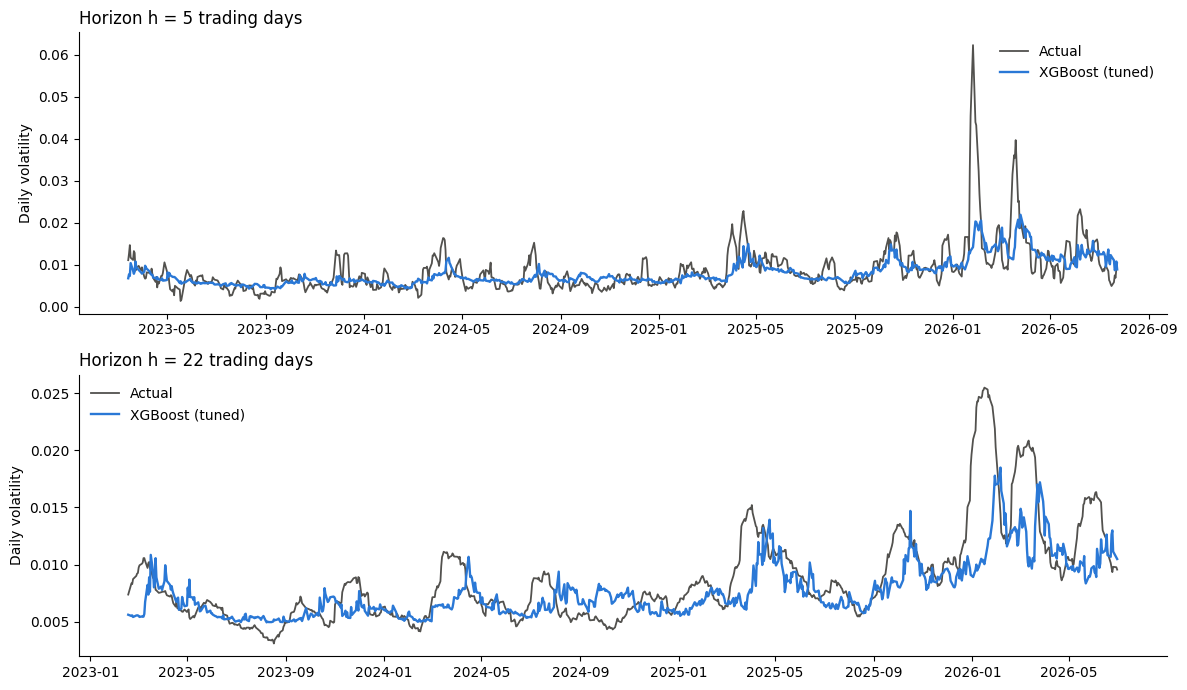

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
for ax, (te, tgt, preds, hh) in zip(axes, [(test_5, target_5, preds_5, 5),
                                           (test_22, target_22, preds_22, 22)]):
    ax.plot(te.index, np.exp(te[tgt]), color="#52514e", lw=1.3, label="Actual")
    ax.plot(te.index, preds["XGBoost (tuned)"], color="#2a78d6", lw=1.7,
            label="XGBoost (tuned)")
    ax.set_title(f"Horizon h = {hh} trading days", loc="left")
    ax.set_ylabel("Daily volatility")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
show("actual_vs_predicted")

## 7. Statistical Significance (Diebold-Mariano)

Newey-West with `h-1` lags, because overlapping forecast windows autocorrelate
the loss differentials.

In [11]:
def dm_table(preds, te, tgt, horizon):
    actual = np.exp(te[tgt].to_numpy())
    model_loss = qlike_loss(actual, preds["XGBoost (tuned)"])
    rows = []
    for name in ("Persistence", "HAR (linear)", "XGBoost (default)"):
        stat, pval = diebold_mariano(model_loss, qlike_loss(actual, preds[name]), horizon)
        rows.append({"Horizon": horizon, "Comparison": f"XGBoost (tuned) vs {name}",
                     "DM_statistic": stat, "p_value": pval,
                     "Significant_5pct": bool(pval < 0.05)})
    return pd.DataFrame(rows)


dm_all = pd.concat([dm_table(preds_5, test_5, target_5, 5),
                    dm_table(preds_22, test_22, target_22, 22)], ignore_index=True)
dm_all

,Horizon,Comparison,DM_statistic,p_value,Significant_5pct
0,5,XGBoost (tuned) vs Persistence,-3.842880,1.215991e-04,True
1,5,XGBoost (tuned) vs HAR (linear),-3.308773,9.370577e-04,True
2,5,XGBoost (tuned) vs XGBoost (default),-6.392152,1.635669e-10,True
3,22,XGBoost (tuned) vs Persistence,-3.265575,1.092421e-03,True
4,22,XGBoost (tuned) vs HAR (linear),-2.258922,2.388823e-02,True
5,22,XGBoost (tuned) vs XGBoost (default),-3.654764,2.574187e-04,True


### 7.1 Model comparison

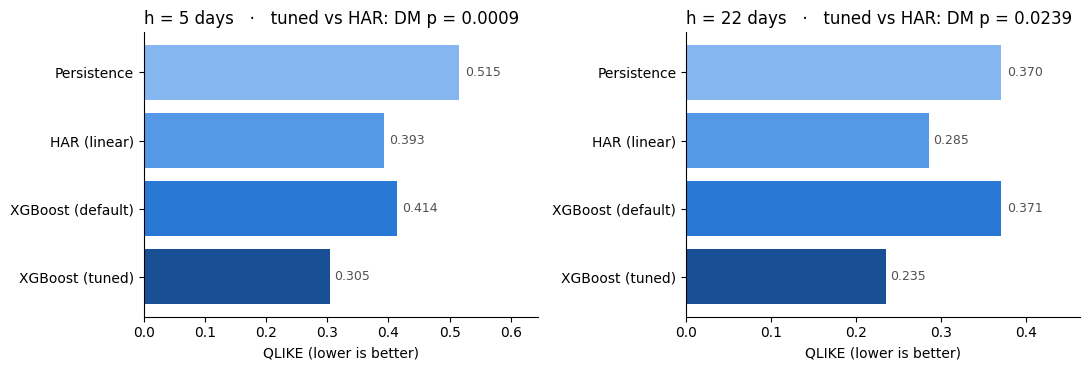

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, hh in zip(axes, (5, 22)):
    sub = all_metrics[all_metrics["Horizon"] == hh]
    p = dm_all[(dm_all.Horizon == hh) &
               (dm_all.Comparison == "XGBoost (tuned) vs HAR (linear)")]["p_value"].iloc[0]
    ax.barh(sub["Model"], sub["QLIKE"],
            color=["#86b6ef", "#5598e7", "#2a78d6", "#184f95"])
    for y, v in enumerate(sub["QLIKE"]):
        ax.text(v * 1.02, y, f"{v:.3f}", va="center", fontsize=9, color="#52514e")
    ax.invert_yaxis()
    ax.set_xlim(0, sub["QLIKE"].max() * 1.25)
    ax.set_xlabel("QLIKE (lower is better)")
    ax.set_title(f"h = {hh} days   ·   tuned vs HAR: DM p = {p:.4f}", loc="left")
    ax.spines[["top", "right"]].set_visible(False)
show("model_comparison")

## 8. Feature Importance

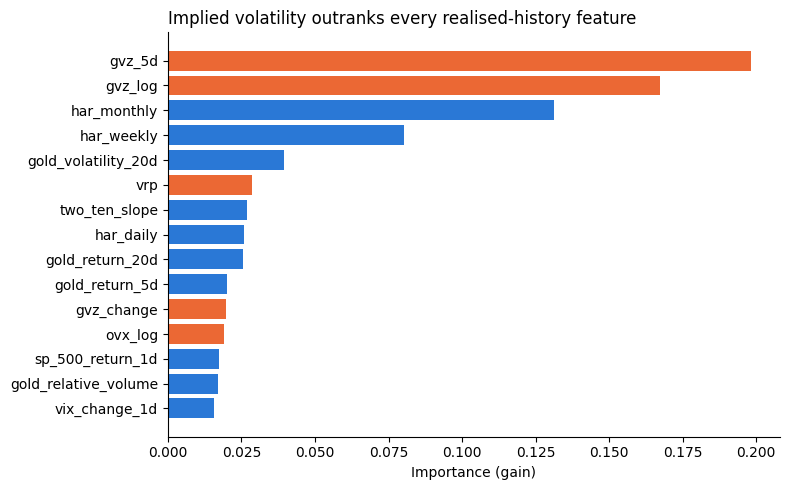

,Feature,Importance
0,gvz_5d,0.198160
1,gvz_log,0.167390
2,har_monthly,0.131283
3,har_weekly,0.080293
4,gold_volatility_20d,0.039531
5,vrp,0.028529
6,two_ten_slope,0.027035
7,har_daily,0.025895
8,gold_return_20d,0.025533
9,gold_return_5d,0.020186


In [13]:
importance = pd.DataFrame({
    "Feature": ALL_FEATURES,
    "Importance": model_5.feature_importances_,
}).sort_values("Importance", ascending=False).reset_index(drop=True)

top = importance.head(15).iloc[::-1]
colors = ["#eb6834" if f in IMPLIED_FEATURES else "#2a78d6" for f in top["Feature"]]
plt.figure(figsize=(8, 5))
plt.barh(top["Feature"], top["Importance"], color=colors)
plt.xlabel("Importance (gain)")
plt.title("Implied volatility outranks every realised-history feature", loc="left")
plt.gca().spines[["top", "right"]].set_visible(False)
show("feature_importance")
importance.head(10)

## 9. Ablations

### 9.1 Volatility estimator: Yang-Zhang versus Parkinson

R^2 is not comparable across the two rows because the target differs; the
Diebold-Mariano column is the valid comparison.

In [14]:
estimator_rows = []
for label, prefix in (("Yang-Zhang (overnight gap + intraday)", ""),
                      ("Parkinson (intraday range only)", "park_")):
    har_cols = [prefix + f for f in HAR_FEATURES]
    features = har_cols + MACRO_FEATURES + IMPLIED_FEATURES
    tgt, ref = f"{prefix}vol_target_5d", f"{prefix}vol_current_5d"
    tr, te = make_split(data, features, tgt, ref, 5)

    bp, _ = tune(tr, features, tgt, 5)
    _, pred = fit_xgb(tr, te, features, tgt, bp)
    row = score(label, te[tgt], pred, te[ref], 5)

    hp = fit_har(tr, te, tgt, har_cols)
    actual = np.exp(te[tgt].to_numpy())
    stat, pval = diebold_mariano(qlike_loss(actual, np.exp(pred)),
                                 qlike_loss(actual, np.exp(hp)), 5)
    row.update({"DM_vs_HAR": stat, "DM_p_value": pval})
    estimator_rows.append(row)

estimator_ablation = pd.DataFrame(estimator_rows).drop(columns=["Model"])
estimator_ablation.insert(0, "Estimator", [r["Model"] for r in estimator_rows])
estimator_ablation

,Estimator,Horizon,MAE,RMSE,R2_log,R2_level,QLIKE,Directional_Accuracy,DM_vs_HAR,DM_p_value
0,Yang-Zhang (overnight gap + intraday),5,0.002462,0.004198,0.485392,0.415691,0.305142,0.700124,-3.308773,0.000937
1,Parkinson (intraday range only),5,0.002169,0.003872,0.426402,0.360110,0.367428,0.690211,-1.713665,0.086590


### 9.2 Feature set

In [15]:
feature_sets = {
    "HAR only": HAR_FEATURES,
    "Macro / cross-asset only": MACRO_FEATURES,
    "HAR + macro (original set)": HAR_FEATURES + MACRO_FEATURES,
    "HAR + implied volatility": HAR_FEATURES + IMPLIED_FEATURES,
    "HAR + macro + implied (full)": ALL_FEATURES,
}

common = data.dropna(subset=ALL_FEATURES + ["vol_target_5d", "vol_current_5d"])
cut = int(len(common) * (1 - TEST_FRACTION))
tr_c, te_c = common.iloc[:cut - 5], common.iloc[cut:]

rows = []
for label, feats in feature_sets.items():
    bp, _ = tune(tr_c, feats, "vol_target_5d", 5)
    _, pred = fit_xgb(tr_c, te_c, feats, "vol_target_5d", bp)
    row = score(label, te_c["vol_target_5d"], pred, te_c["vol_current_5d"], 5)
    row["N_features"] = len(feats)
    rows.append(row)

feature_ablation = pd.DataFrame(rows).rename(columns={"Model": "Feature_set"})
feature_ablation[["Feature_set", "N_features", "R2_log", "R2_level", "QLIKE"]]

,Feature_set,N_features,R2_log,R2_level,QLIKE
0,HAR only,3,0.359214,0.286960,0.392533
1,Macro / cross-asset only,21,0.458587,0.351206,0.361236
2,HAR + macro (original set),24,0.477278,0.373526,0.342960
3,HAR + implied volatility,8,0.445301,0.401707,0.312979
4,HAR + macro + implied (full),29,0.485392,0.415691,0.305142


### 9.3 Both ablations

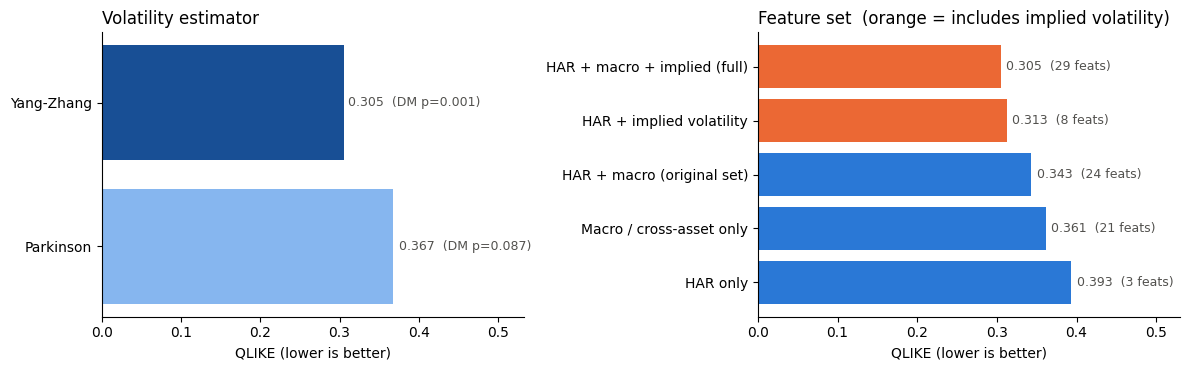

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

est = estimator_ablation.iloc[::-1]
axes[0].barh(est["Estimator"].str.replace(r" \(.*", "", regex=True), est["QLIKE"],
             color=["#86b6ef", "#184f95"])
for y, (v, p) in enumerate(zip(est["QLIKE"], est["DM_p_value"])):
    axes[0].text(v * 1.02, y, f"{v:.3f}  (DM p={p:.3f})", va="center",
                 fontsize=9, color="#52514e")
axes[0].set_xlim(0, est["QLIKE"].max() * 1.45)
axes[0].set_title("Volatility estimator", loc="left")

feat = feature_ablation.sort_values("QLIKE", ascending=False)
axes[1].barh(feat["Feature_set"], feat["QLIKE"],
             color=["#eb6834" if "implied" in f else "#2a78d6" for f in feat["Feature_set"]])
for y, (v, n) in enumerate(zip(feat["QLIKE"], feat["N_features"])):
    axes[1].text(v * 1.02, y, f"{v:.3f}  ({n} feats)", va="center",
                 fontsize=9, color="#52514e")
axes[1].set_xlim(0, feat["QLIKE"].max() * 1.35)
axes[1].set_title("Feature set  (orange = includes implied volatility)", loc="left")

for ax in axes:
    ax.set_xlabel("QLIKE (lower is better)")
    ax.spines[["top", "right"]].set_visible(False)
show("ablations")

## 10. Volatility-Direction Classifier

Binary framing of the same problem, which supports ROC-AUC and a confusion
matrix.

In [17]:
def run_classifier(horizon):
    tgt, ref = f"vol_target_{horizon}d", f"vol_current_{horizon}d"
    frame = data.dropna(subset=ALL_FEATURES + [tgt, ref]).copy()
    frame["label"] = (frame[tgt] > frame[ref]).astype(int)
    cut = int(len(frame) * (1 - TEST_FRACTION))
    tr, te = frame.iloc[:cut - horizon], frame.iloc[cut:]

    clf = xgb.XGBClassifier(n_estimators=400, max_depth=3, learning_rate=0.02,
                            subsample=0.8, colsample_bytree=0.6, reg_lambda=5.0,
                            random_state=SEED, n_jobs=4, eval_metric="logloss")
    clf.fit(tr[ALL_FEATURES], tr["label"])
    y_true = te["label"].to_numpy()
    proba = clf.predict_proba(te[ALL_FEATURES])[:, 1]
    y_pred = clf.predict(te[ALL_FEATURES])
    metrics = {
        "Horizon": horizon,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Majority_Baseline": max(y_true.mean(), 1 - y_true.mean()),
        "ROC_AUC": roc_auc_score(y_true, proba),
        "PR_AUC": average_precision_score(y_true, proba),
        "F1": f1_score(y_true, y_pred),
        "N_test": len(te),
    }
    return metrics, y_true, proba, y_pred


clf_rows, roc_data = [], {}
for hh in (5, 22):
    m, y_true, proba, y_pred = run_classifier(hh)
    clf_rows.append(m)
    roc_data[hh] = (y_true, proba, y_pred)
clf_metrics = pd.DataFrame(clf_rows)
clf_metrics

,Horizon,Accuracy,Majority_Baseline,ROC_AUC,PR_AUC,F1,N_test
0,5,0.686493,0.503098,0.767883,0.775382,0.662216,807
1,22,0.686957,0.541615,0.789774,0.733352,0.582781,805


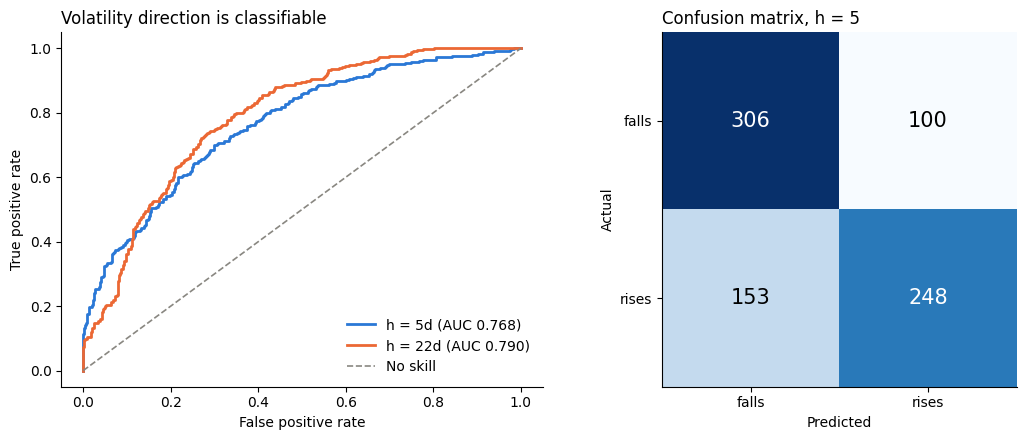

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for hh, color in ((5, "#2a78d6"), (22, "#eb6834")):
    y_true, proba, _ = roc_data[hh]
    fpr, tpr, _ = roc_curve(y_true, proba)
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f"h = {hh}d (AUC {roc_auc_score(y_true, proba):.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="#898781", lw=1.2, label="No skill")
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("Volatility direction is classifiable", loc="left")
axes[0].legend(frameon=False)

y_true, _, y_pred = roc_data[5]
cm = confusion_matrix(y_true, y_pred)
axes[1].imshow(cm, cmap="Blues")
axes[1].set_xticks([0, 1], ["falls", "rises"]); axes[1].set_yticks([0, 1], ["falls", "rises"])
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion matrix, h = 5", loc="left")
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm[i, j], ha="center", va="center", fontsize=15,
                     color="white" if cm[i, j] > cm.max() * 0.6 else "black")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
show("direction_roc")

## 11. One-Year Walk-Forward Backtest

Train only on data from before the last year, then walk forward day by day,
refitting on everything that has already resolved. Scored against a 20-day
trailing average, which costs nothing.

In [19]:
BACKTEST_START = "2025-07-31"
BT_PARAMS = dict(n_estimators=300, max_depth=3, learning_rate=0.03,
                 subsample=0.7, colsample_bytree=0.5, min_child_weight=20,
                 reg_lambda=5.0, random_state=SEED, n_jobs=4)

bt = data.copy()
bt["y1"] = bt["har_daily"].shift(-1)                  # next-day log volatility
bt["realised"] = np.exp(bt["y1"])
bt["naive"] = bt["gold_return_1d"].rolling(20).std()  # free comparator
bt["gold_next"] = np.expm1(bt["tomorrow_gold_log_return"])
bt = bt.dropna(subset=ALL_FEATURES + ["y1", "gold_next", "naive"])

pre, window = bt.loc[bt.index < BACKTEST_START], bt.loc[BACKTEST_START:]
assert pre.index.max() < window.index.min()
print(f"Train on      {pre.index.min().date()} to {pre.index.max().date()}  ({len(pre)} rows)")
print(f"Walk forward  {window.index.min().date()} to {window.index.max().date()}  ({len(window)} rows)")

records = []
for i, date in enumerate(window.index, 1):
    pos = bt.index.get_loc(date)
    history = bt.iloc[:pos]          # every label here has already resolved
    model = xgb.XGBRegressor(**BT_PARAMS).fit(history[ALL_FEATURES], history["y1"])
    bias = smearing(history["y1"] - model.predict(history[ALL_FEATURES]))
    row = bt.loc[[date]]
    records.append({
        "Date": date,
        "forecast": float(np.exp(model.predict(row[ALL_FEATURES])[0] + bias)),
        "naive": float(row["naive"].iloc[0]),
        "realised": float(row["realised"].iloc[0]),
        "gold_next": float(row["gold_next"].iloc[0]),
    })
    if i % 50 == 0:
        print(f"  {i}/{len(window)} days")

wf = pd.DataFrame(records).set_index("Date")
print()
print(f"Forecast R2 on log volatility: "
      f"{r2_score(np.log(wf.realised), np.log(wf.forecast)):+.3f}")
print(f"Model RMSE {np.sqrt(np.mean((wf.realised - wf.forecast) ** 2)):.5f}  "
      f"vs naive 20d {np.sqrt(np.mean((wf.realised - wf.naive) ** 2)):.5f}")

Train on      2008-07-28 to 2025-07-30  (3633 rows)
Walk forward  2025-07-31 to 2026-07-29  (237 rows)


  50/237 days


  100/237 days


  150/237 days


  200/237 days



Forecast R2 on log volatility: +0.172
Model RMSE 0.00840  vs naive 20d 0.01127


### 11.1 Trading the forecast from a $1,000 stake

The forecast cannot pick direction -- returns are not predictable -- but it can
*size* a position: hold more gold when volatility is forecast to be low,
targeting a constant 10% annualised risk. Net of 2bp costs on turnover.

The naive line applies the identical rule to a 20-day trailing average, which
costs nothing. The gap between it and the model line is what the forecast
contributes; the gap to buy-and-hold is mostly the sizing rule itself.

In [20]:
STAKE = 1000.0
COST = 0.0002              # 2 bps of traded notional
TARGET_ANNUAL_VOL = 0.10   # size the position to a constant 10% annual risk
MAX_LEVERAGE = 3.0

equity = pd.DataFrame(index=wf.index)
equity["Gold buy & hold"] = STAKE * (1 + wf["gold_next"]).cumprod()

for label, vol in (("Vol-targeted gold (naive 20d)", wf["naive"]),
                   ("Vol-targeted gold (model)", wf["forecast"])):
    weight = (TARGET_ANNUAL_VOL / np.sqrt(252) / vol).clip(0, MAX_LEVERAGE)
    turnover = np.abs(np.diff(np.r_[0.0, weight]))
    equity[label] = STAKE * (1 + weight * wf["gold_next"] - turnover * COST).cumprod()

summary = pd.DataFrame([{
    "Strategy": name,
    "Final $": curve.iloc[-1],
    "Profit $": curve.iloc[-1] - STAKE,
    "Return %": 100 * (curve.iloc[-1] / STAKE - 1),
    "Sharpe": np.sqrt(252) * curve.pct_change().mean() / curve.pct_change().std(),
    "Max DD %": 100 * (curve / curve.cummax() - 1).min(),
} for name, curve in equity.items()])
summary

,Strategy,Final $,Profit $,Return %,Sharpe,Max DD %
0,Gold buy & hold,1097.082939,97.082939,9.708294,0.430403,-27.466656
1,Vol-targeted gold (naive 20d),1091.246872,91.246872,9.124687,0.697769,-14.906707
2,Vol-targeted gold (model),1186.314516,186.314516,18.631452,1.256949,-16.234814


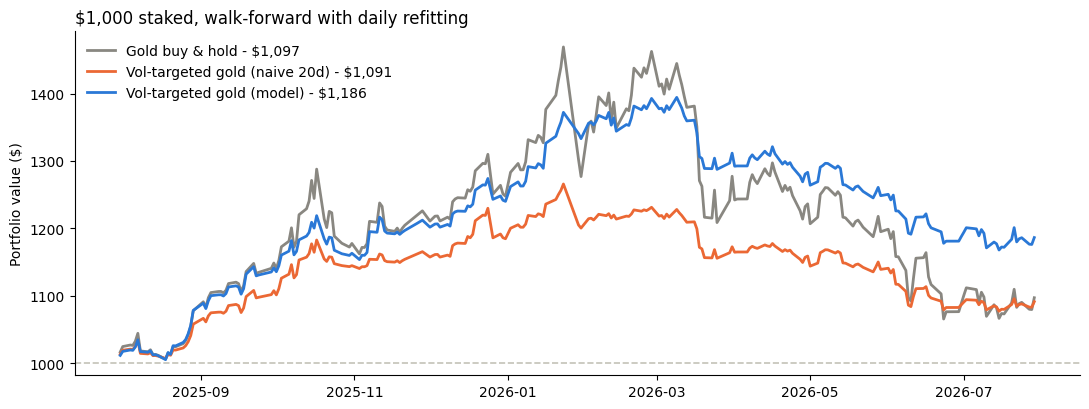

In [21]:
series = [("Gold buy & hold", "#898781"),
          ("Vol-targeted gold (naive 20d)", "#eb6834"),
          ("Vol-targeted gold (model)", "#2a78d6")]

plt.figure(figsize=(11, 4.2))
for name, color in series:
    # Final value goes in the legend: two of the three curves finish within
    # $6 of each other, so end-of-line labels would sit on top of one another
    plt.plot(equity.index, equity[name], color=color, lw=2,
             label=f"{name} - ${equity[name].iloc[-1]:,.0f}")
plt.axhline(STAKE, color="#c3c2b7", ls="--", lw=1.2)
plt.ylabel("Portfolio value ($)")
plt.title("$1,000 staked, walk-forward with daily refitting", loc="left")
plt.legend(frameon=False, loc="upper left")
plt.gca().spines[["top", "right"]].set_visible(False)
show("backtest_equity")